========== CUSTOMER DATASET ==========
    CustomerID  Age  Annual_Income  Spending_Score
0            1   19          15000              85
1            2   21          18000              90
2            3   22          20000              88
3            4   25          22000              80
4            5   28          25000              82
5            6   31          30000              75
6            7   35          35000              70
7            8   40          40000              65
8            9   42          45000              60
9           10   45          50000              55
10          11   48          55000              50
11          12   50          60000              45
12          13   52          65000              40
13          14   55          70000              35
14          15   58          75000              30
15          16   60          80000              25
16          17   62          85000              20
17          18   65          90000         

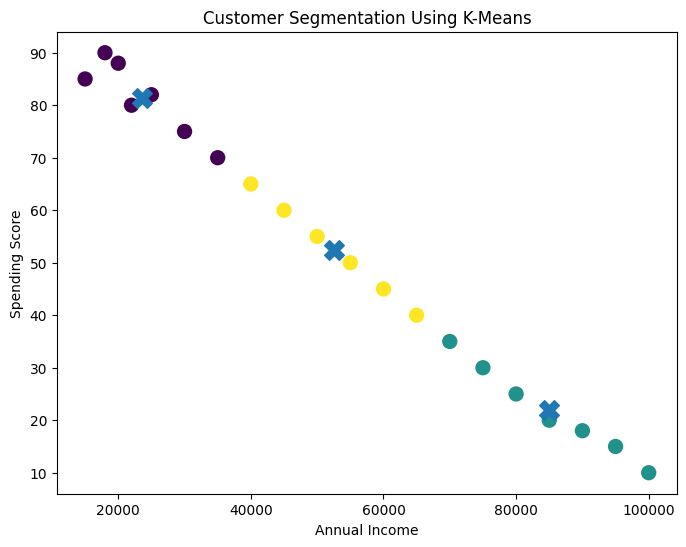


========== CUSTOMERS PER CLUSTER ==========
Cluster
0    7
1    7
2    6
Name: count, dtype: int64

========== CLUSTER SUMMARY ==========
               Age  Annual_Income  Spending_Score
Cluster                                          
0        25.857143   23571.428571       81.428571
1        62.428571   85000.000000       21.857143
2        46.166667   52500.000000       52.500000


In [6]:
# ============================================================
# CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. CREATE DATASET
# ============================================================

data = {
    "CustomerID": range(1, 21),

    "Age": [
        19, 21, 22, 25, 28,
        31, 35, 40, 42, 45,
        48, 50, 52, 55, 58,
        60, 62, 65, 67, 70
    ],

    "Annual_Income": [
        15000, 18000, 20000, 22000, 25000,
        30000, 35000, 40000, 45000, 50000,
        55000, 60000, 65000, 70000, 75000,
        80000, 85000, 90000, 95000, 100000
    ],

    "Spending_Score": [
        85, 90, 88, 80, 82,
        75, 70, 65, 60, 55,
        50, 45, 40, 35, 30,
        25, 20, 18, 15, 10
    ]
}

df = pd.DataFrame(data)


# ============================================================
# 2. DISPLAY DATASET
# ============================================================

print("========== CUSTOMER DATASET ==========")
print(df)

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 3. SELECT FEATURES
# ============================================================

X = df[
    [
        "Annual_Income",
        "Spending_Score"
    ]
]


# ============================================================
# 4. STANDARDIZE THE DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 5. APPLY K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)


# ============================================================
# 6. DISPLAY CLUSTERED DATA
# ============================================================

print("\n========== CUSTOMER SEGMENTS ==========")

print(
    df[
        [
            "CustomerID",
            "Age",
            "Annual_Income",
            "Spending_Score",
            "Cluster"
        ]
    ]
)


# ============================================================
# 7. DISPLAY CLUSTER CENTERS
# ============================================================

centers_scaled = kmeans.cluster_centers_

centers = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(
    centers,
    columns=[
        "Annual_Income",
        "Spending_Score"
    ]
)

print("\n========== CLUSTER CENTERS ==========")
print(centers_df)


# ============================================================
# 8. VISUALIZE CUSTOMER SEGMENTS
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title("Customer Segmentation Using K-Means")

plt.show()


# ============================================================
# 9. COUNT CUSTOMERS IN EACH CLUSTER
# ============================================================

print("\n========== CUSTOMERS PER CLUSTER ==========")

print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 10. CLUSTER SUMMARY
# ============================================================

summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual_Income",
        "Spending_Score"
    ]
].mean()

print("\n========== CLUSTER SUMMARY ==========")

print(summary)